In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
df=pd.read_csv("/content/diabetic_data.csv")

In [61]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [62]:
df.shape

(101766, 50)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [64]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


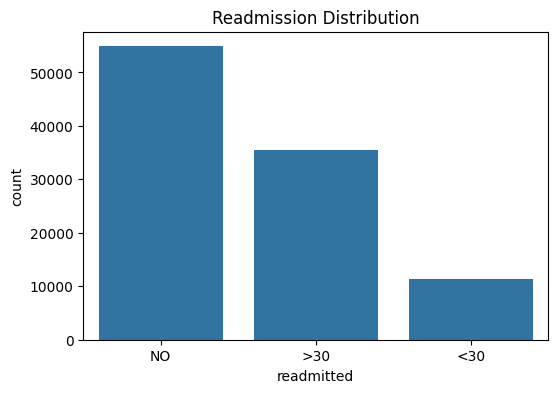

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(x='readmitted',data=df)

plt.title("Readmission Distribution")
plt.show()

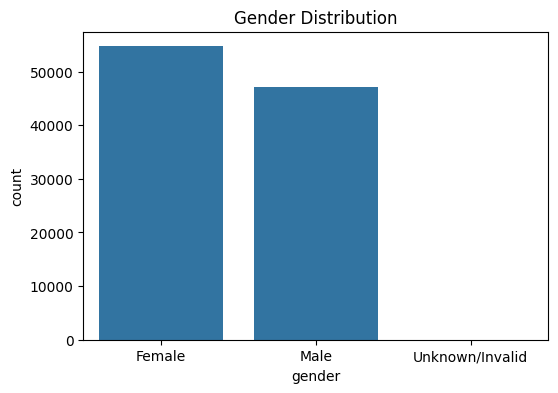

In [66]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender',data=df)

plt.title("Gender Distribution")
plt.show()

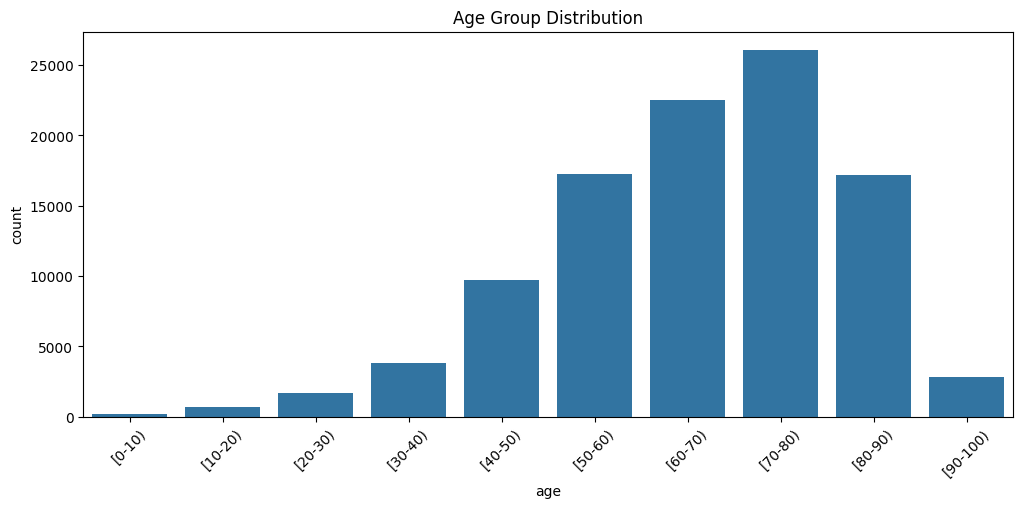

In [67]:
plt.figure(figsize=(12,5))

sns.countplot(x='age',data=df)

plt.xticks(rotation=45)

plt.title("Age Group Distribution")
plt.show()

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [70]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [71]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [72]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

In [73]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

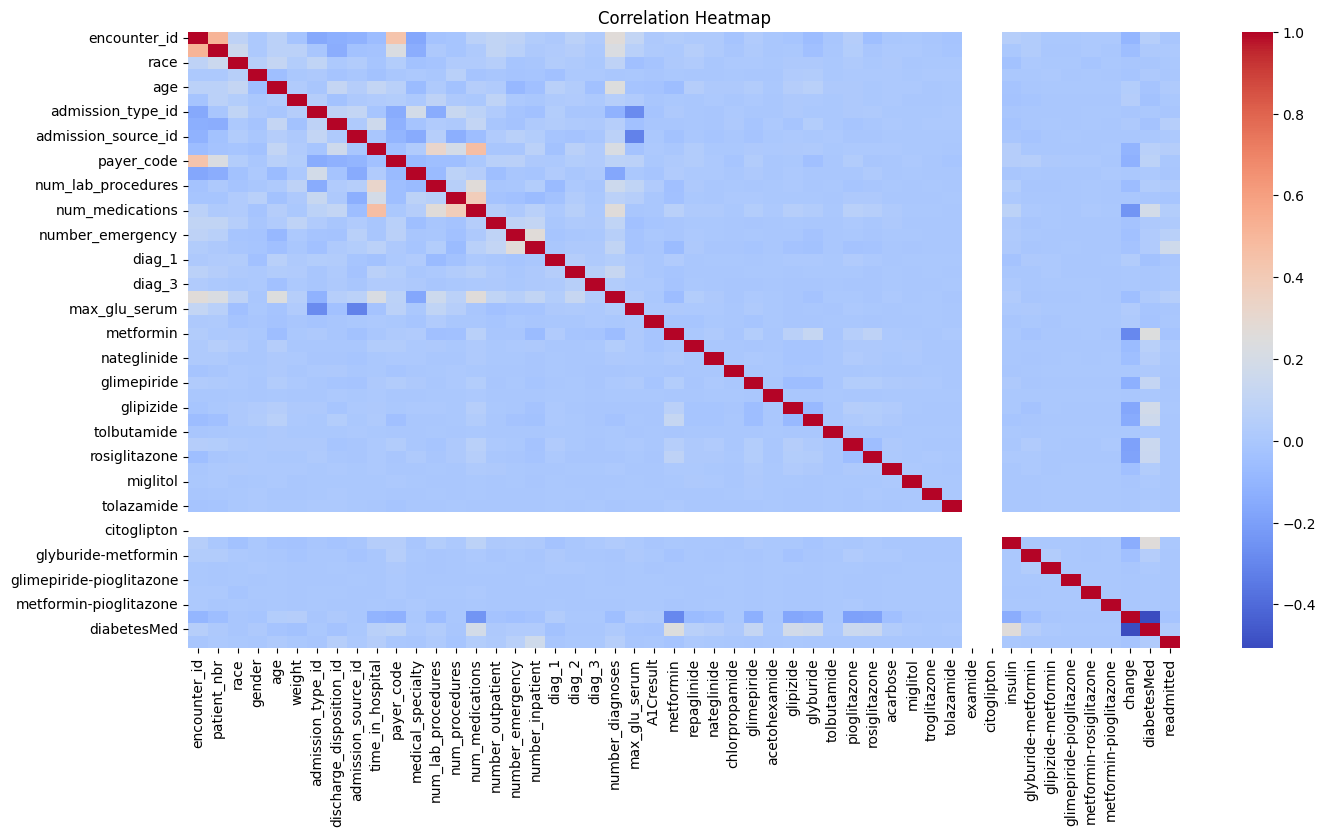

In [74]:
plt.figure(figsize=(16,8))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [75]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [77]:
model = RandomForestClassifier(n_estimators=100,random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred = model.predict(X_test)

In [79]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test,y_pred))

Accuracy: 0.887737054141692
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.50      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.69      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



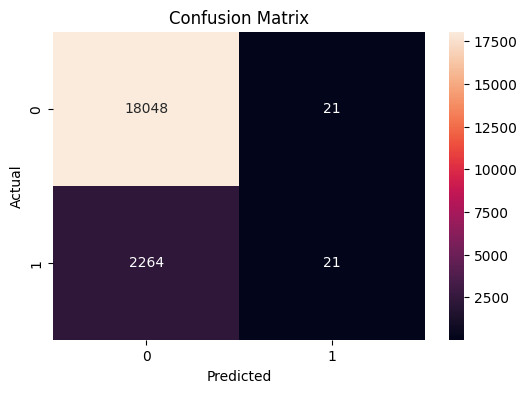

In [80]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

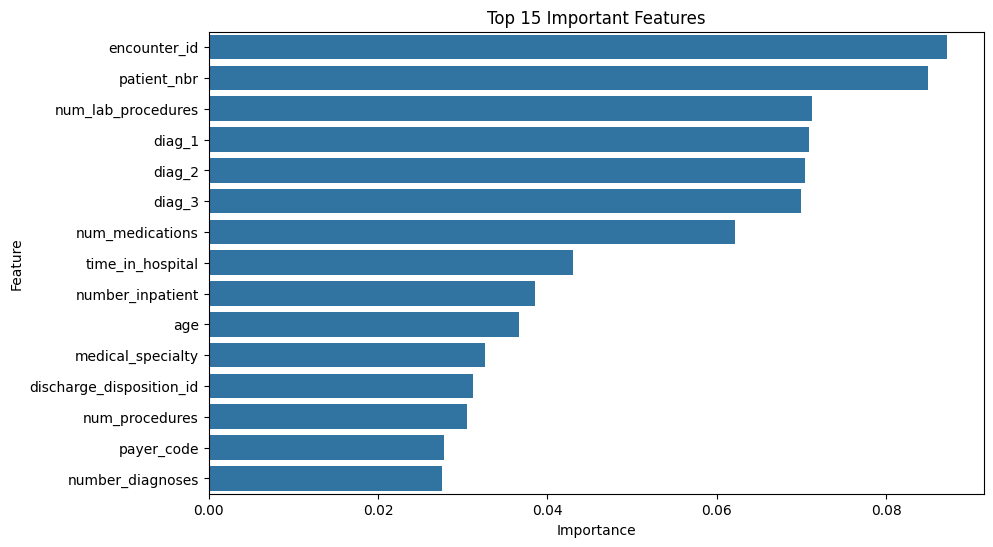

In [81]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(x='Importance',y='Feature',data=feature_importance.head(15))

plt.title("Top 15 Important Features")

plt.show()

In [82]:
sample_patient = np.array(
    [X.iloc[0]]
)

prediction = model.predict(sample_patient)

if prediction[0] == 1:
    print("Patient likely to be readmitted")
else:
    print("Patient not likely to be readmitted")

Patient not likely to be readmitted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
